In [1]:
import sys
import os

notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import StatsBombLoader
from src.data.preprocessing import PassPreprocessor
from src.data.feature_engineering import FeatureExtractor

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("Librerías cargadas")

Librerías cargadas


In [2]:
"""
FEATURE ENGINEERING - FC BARCELONA
Análisis de Estrategias de Juego mediante Grafos y ML
"""


print("Equipo objetivo: FC Barcelona")
print("Fuente: StatsBomb Open Data")

LALIGA_SEASONS = [
    {'season_id': 90,  'season_name': '2020/2021'},
    {'season_id': 42,  'season_name': '2019/2020'},
    {'season_id': 4,   'season_name': '2018/2019'},
    
]

COMPETITION_ID = 11  # La Liga

print(f"\nTemporadas a cargar: {len(LALIGA_SEASONS)}")
print(f"Partidos estimados por temporada: ~35")
print(f"Total instancias estimadas: ~{len(LALIGA_SEASONS) * 35 * 2} (Barcelona + rival por partido)")

Equipo objetivo: FC Barcelona
Fuente: StatsBomb Open Data

Temporadas a cargar: 3
Partidos estimados por temporada: ~35
Total instancias estimadas: ~210 (Barcelona + rival por partido)


In [3]:
# CARGA DE PARTIDOS DEL FC BARCELONA - TODAS LAS TEMPORADAS

loader = StatsBombLoader()
all_barcelona_matches = []

print(" Cargando partidos de Barcelona en todas las temporadas...\n")

for season in LALIGA_SEASONS:
    season_id = season['season_id']
    season_name = season['season_name']
    
    try:
        matches = loader.get_matches(
            competition_id=COMPETITION_ID, 
            season_id=season_id
        )
        
        # Filtramos partidos de Barcelona
        barca_matches = matches[
            (matches['home_team'] == 'Barcelona') | 
            (matches['away_team'] == 'Barcelona')
        ].copy()
        
        # Añadir info de temporada
        barca_matches['season_name'] = season_name
        barca_matches['season_id'] = season_id
        
        all_barcelona_matches.append(barca_matches)
        print(f" {season_name}: {len(barca_matches)} partidos")
        
    except Exception as e:
        print(f" {season_name}: Error - {e}")

# Combinar todas las temporadas
barcelona_matches = pd.concat(all_barcelona_matches, ignore_index=True)

print(f" TOTAL PARTIDOS CARGADOS: {len(barcelona_matches)}")
print(f"   - Temporadas: {barcelona_matches['season_name'].nunique()}")
print(f"   - Como local: {(barcelona_matches['home_team'] == 'Barcelona').sum()}")
print(f"   - Como visitante: {(barcelona_matches['away_team'] == 'Barcelona').sum()}")

# Resultados históricos de Barcelona
def classify_result(row, team):
    if row['home_team'] == team:
        if row['home_score'] > row['away_score']: return 'V'
        elif row['home_score'] < row['away_score']: return 'D'
        else: return 'E'
    else:
        if row['away_score'] > row['home_score']: return 'V'
        elif row['away_score'] < row['home_score']: return 'D'
        else: return 'E'

barcelona_matches['resultado_barca'] = barcelona_matches.apply(
    lambda row: classify_result(row, 'Barcelona'), axis=1
)

results_count = barcelona_matches['resultado_barca'].value_counts()
print(f"\n Resultados históricos de Barcelona:")
print(f"   - Victorias: {results_count.get('V', 0)}")
print(f"   - Empates:   {results_count.get('E', 0)}")
print(f"   - Derrotas:  {results_count.get('D', 0)}")

 Data directory: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw
 Cargando partidos de Barcelona en todas las temporadas...



C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


 Partidos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\matches_11_90.csv
 2020/2021: 35 partidos


C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


 Partidos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\matches_11_42.csv
 2019/2020: 33 partidos


C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


 Partidos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\matches_11_4.csv
 2018/2019: 34 partidos
 TOTAL PARTIDOS CARGADOS: 102
   - Temporadas: 3
   - Como local: 53
   - Como visitante: 49

 Resultados históricos de Barcelona:
   - Victorias: 68
   - Empates:   20
   - Derrotas:  14


In [4]:
# PREPROCESAMIENTO DE PARTIDOS

preprocessor = PassPreprocessor()
matches_data = []

print("\n Procesando partidos de Barcelona...")


successful = 0
failed = 0
events_cache = {}  # Cache para reutilizar eventos

for idx, match_row in barcelona_matches.iterrows():
    match_id = match_row['match_id']
    home_team = match_row['home_team']
    away_team = match_row['away_team']
    
    print(f"\n[{successful + failed + 1}/{len(barcelona_matches)}] {home_team} vs {away_team}")
    
    try:
        # Cargar eventos
        events, _ = loader.load_match_data(match_id)
        events_cache[match_id] = events  # Guardar para xG después
        
        passes_clean = preprocessor.preprocess_full_pipeline(events)
        
        # Barcelona
        barca_passes = len(passes_clean[passes_clean['team'] == 'Barcelona'])
        if barca_passes >= 10:
            matches_data.append((match_id, passes_clean, 'Barcelona'))
            print(f"    Barcelona: {barca_passes} pases")
        else:
            print(f"     Barcelona: solo {barca_passes} pases")
        
        # Rival
        rival = away_team if home_team == 'Barcelona' else home_team
        rival_passes = len(passes_clean[passes_clean['team'] == rival])
        if rival_passes >= 10:
            matches_data.append((match_id, passes_clean, rival))
            print(f"    {rival}: {rival_passes} pases")
        else:
            print(f"     {rival}: solo {rival_passes} pases")
        
        successful += 1
        
    except Exception as e:
        print(f"    Error: {e}")
        failed += 1


print(f" Procesamiento completado:")
print(f"   - Partidos procesados: {successful}/{len(barcelona_matches)}")
print(f"   - Instancias totales: {len(matches_data)}")


# Distribución
teams_in_data = [team for _, _, team in matches_data]
print("\n Distribución de instancias:")
team_dist = pd.Series(teams_in_data).value_counts()
print(team_dist.head(10))


 Procesando partidos de Barcelona...

[1/102] Deportivo Alavés vs Barcelona


C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


 Eventos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\events_3773386.csv
 Partido 3773386:
   - Total eventos: 3891
   - Total pases: 1118
 INICIANDO PIPELINE DE PREPROCESAMIENTO
 Eventos totales: 3891
 Pases encontrados: 1118
 Pases después de eliminar nulos en player/team: 1118
 Precisión de pase: 83.90%
 Pases después de filtrar por distancia: 1118 (eliminados: 0)
 Normalización temporal completada
 Pases con receptor válido: 1060 (eliminados: 58)
 PREPROCESAMIENTO COMPLETADO: 1060 pases válidos
    Barcelona: 850 pases
    Deportivo Alavés: 210 pases

[2/102] Granada vs Barcelona


C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


 Eventos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\events_3773565.csv
 Partido 3773565:
   - Total eventos: 3775
   - Total pases: 1153
 INICIANDO PIPELINE DE PREPROCESAMIENTO
 Eventos totales: 3775
 Pases encontrados: 1153
 Pases después de eliminar nulos en player/team: 1153
 Precisión de pase: 88.46%
 Pases después de filtrar por distancia: 1153 (eliminados: 0)
 Normalización temporal completada
 Pases con receptor válido: 1142 (eliminados: 11)
 PREPROCESAMIENTO COMPLETADO: 1142 pases válidos
    Barcelona: 826 pases
    Granada: 316 pases

[3/102] Barcelona vs Celta Vigo


...

 Eventos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\events_16196.csv
 Partido 16196:
   - Total eventos: 3978
   - Total pases: 1056
 INICIANDO PIPELINE DE PREPROCESAMIENTO
 Eventos totales: 3978
 Pases encontrados: 1056
 Pases después de eliminar nulos en player/team: 1056
 Precisión de pase: 83.62%
 Pases después de filtrar por distancia: 1056 (eliminados: 0)
 Normalización temporal completada
 Pases con receptor válido: 1042 (eliminados: 14)
 PREPROCESAMIENTO COMPLETADO: 1042 pases válidos
    Barcelona: 531 pases
    Real Madrid: 511 pases

[101/102] Real Valladolid vs Barcelona


C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


 Eventos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\events_15956.csv
 Partido 15956:
   - Total eventos: 3342
   - Total pases: 996
 INICIANDO PIPELINE DE PREPROCESAMIENTO
 Eventos totales: 3342
 Pases encontrados: 996
 Pases después de eliminar nulos en player/team: 996
 Precisión de pase: 80.02%
 Pases después de filtrar por distancia: 996 (eliminados: 0)
 Normalización temporal completada
 Pases con receptor válido: 913 (eliminados: 83)
 PREPROCESAMIENTO COMPLETADO: 913 pases válidos
    Barcelona: 557 pases
    Real Valladolid: 356 pases

[102/102] Barcelona vs Espanyol


C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


 Eventos guardados en: C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\raw\events_16231.csv
 Partido 16231:
   - Total eventos: 3814
   - Total pases: 1061
 INICIANDO PIPELINE DE PREPROCESAMIENTO
 Eventos totales: 3814
 Pases encontrados: 1061
 Pases después de eliminar nulos en player/team: 1061
 Precisión de pase: 81.90%
 Pases después de filtrar por distancia: 1061 (eliminados: 0)
 Normalización temporal completada
 Pases con receptor válido: 1028 (eliminados: 33)
 PREPROCESAMIENTO COMPLETADO: 1028 pases válidos
    Barcelona: 719 pases
    Espanyol: 309 pases
 Procesamiento completado:
   - Partidos procesados: 102/102
   - Instancias totales: 204

 Distribución de instancias:
Barcelona           102
Deportivo Alavés      6
Villarreal            6
Levante UD            6
Sevilla               6
Real Sociedad         6
Real Valladolid       6
Atlético Madrid       6
Celta Vigo            5
Valencia              5
Name: count, dtype: int64


In [5]:
# EXTRACCIÓN DE FEATURES

extractor = FeatureExtractor()

print("\n  Extrayendo features...")
print("  Esto puede tardar unos minutos...\n")

df_features = extractor.create_dataset_from_matches(
    matches_data, 
    include_temporal=True
)

extractor.print_feature_summary(df_features)

print(f"\n Features por equipo:")
print(df_features['team'].value_counts())


  Extrayendo features...
  Esto puede tardar unos minutos...

  CONSTRUYENDO DATASET DE FEATURES

[1/204] Match ID: 3773386 - Team: Barcelona

 Extrayendo features para Barcelona...
   - Estadísticas de pases...
   - Grafo estático...

 Construyendo grafo de pases (peso: frequency)...
 Grafo construido:
   - Nodos (jugadores): 16
   - Aristas (conexiones): 152
 Calculando coeficiente de clustering...
 Clustering promedio: 0.1743

 Calculando métricas de centralidad...
 Métricas de centralidad calculadas
   - Grafos dinámicos...

 Construyendo grafos dinámicos...
 Creadas 48 ventanas temporales
   - Tamaño de ventana: 5 min
   - Paso: 2 min

 Construyendo grafo de pases (peso: frequency)...
 Grafo construido:
   - Nodos (jugadores): 10
   - Aristas (conexiones): 33

 Construyendo grafo de pases (peso: frequency)...
 Grafo construido:
   - Nodos (jugadores): 11
   - Aristas (conexiones): 22

 Construyendo grafo de pases (peso: frequency)...
 Grafo construido:
   - Nodos (jugadores): 11


 DISTRIBUCIÓN DE LABELS

 Resultados (todas las instancias):
resultado
victoria    82
derrota     82
empate      40
Name: count, dtype: int64

 Resultados (solo Barcelona):
resultado
victoria    68
empate      20
derrota     14
Name: count, dtype: int64

 Contexto:
contexto
visitante    102
local        102
Name: count, dtype: int64

 Tipo de rival:
tipo_rival
medio     187
grande     17
Name: count, dtype: int64

 Estadísticas de goles:
       goles_equipo  goles_rival
count    204.000000   204.000000
mean       1.637255     1.637255
std        1.467475     1.467475
min        0.000000     0.000000
25%        0.750000     0.750000
50%        1.000000     1.000000
75%        2.000000     2.000000
max        8.000000     8.000000

 Estadísticas de xG:
        xg_equipo    xg_rival     xg_diff
count  204.000000  204.000000  204.000000
mean     1.425682    1.425682    0.000000
std      0.893693    0.893693    1.398564
min      0.089312    0.089312   -3.305898
25%      0.746455    0.746455

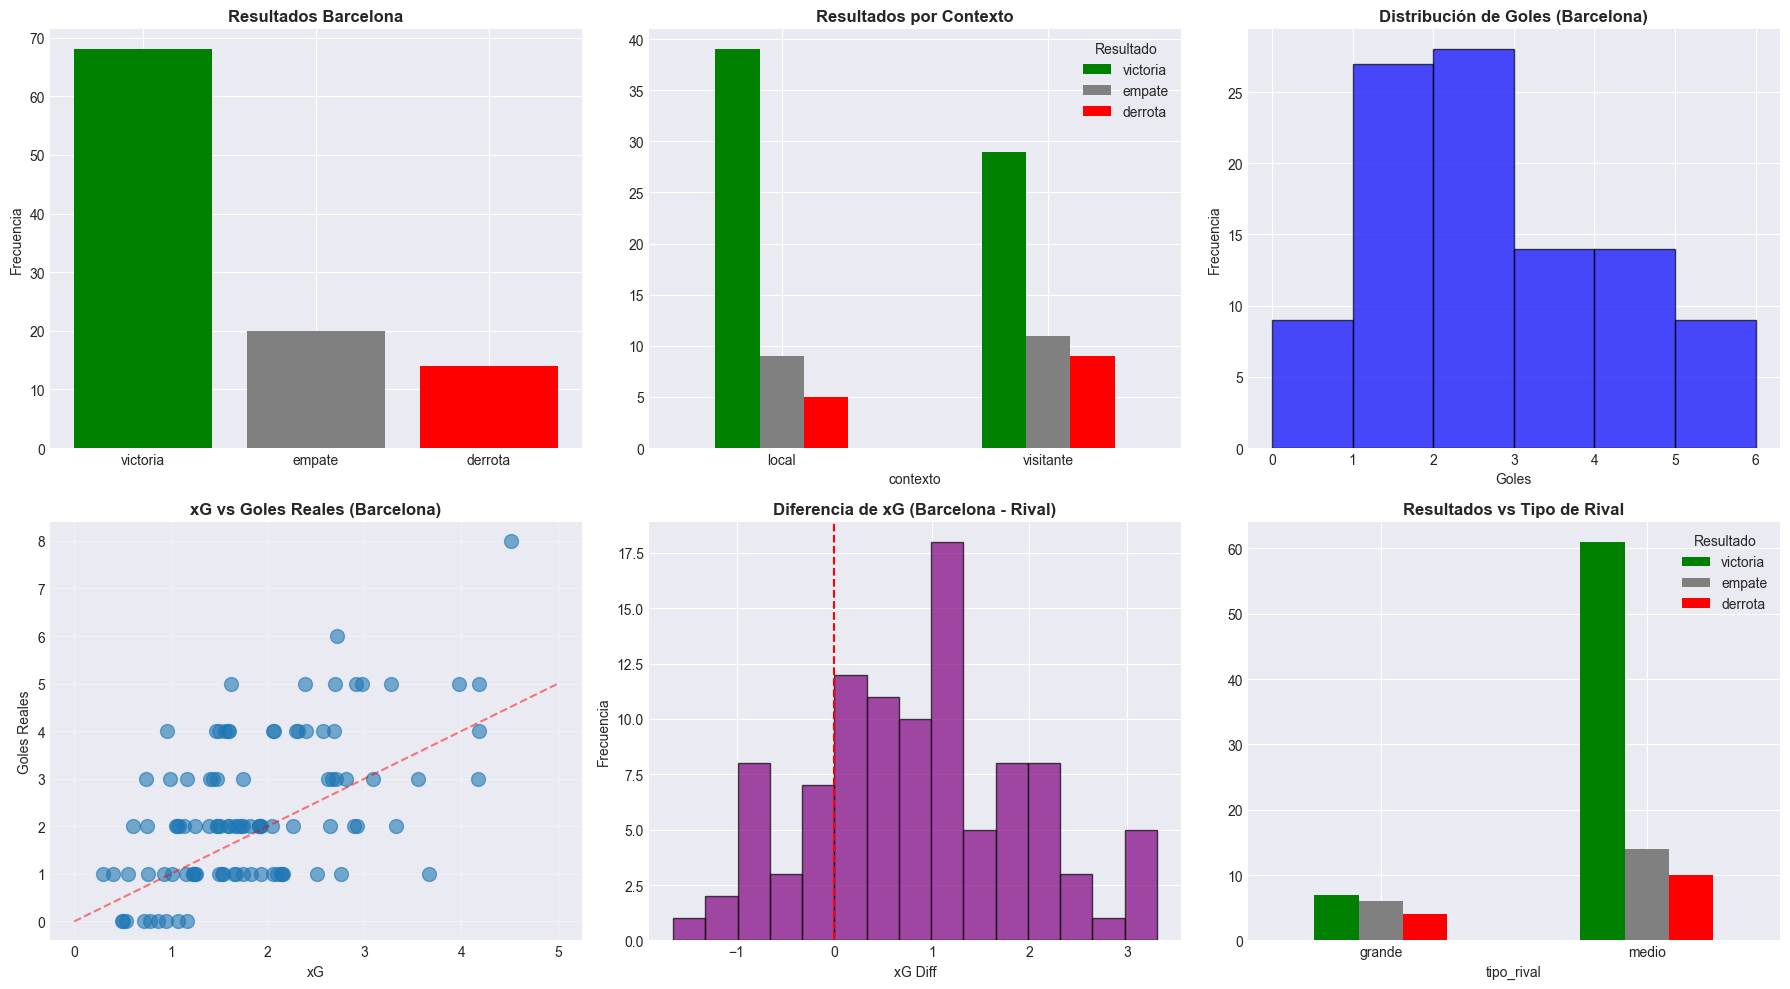

In [6]:
# SECCIÓN PARA LABELS Y CONTEXTP

def add_match_context(row, matches_df, events_cache):
    """
    Añade información completa del partido: resultado, xG, contexto.
    """
    match_id = row['match_id']
    team = row['team']
    
    # Info del partido
    match_info = matches_df[matches_df['match_id'] == match_id].iloc[0]
    
    home_team = match_info['home_team']
    away_team = match_info['away_team']
    home_score = match_info['home_score']
    away_score = match_info['away_score']
    
    is_home = (team == home_team)
    is_barcelona = (team == 'Barcelona')
    rival = away_team if is_home else home_team
    
    # resultado
    if home_score > away_score:
        resultado = 'victoria' if is_home else 'derrota'
    elif home_score < away_score:
        resultado = 'derrota' if is_home else 'victoria'
    else:
        resultado = 'empate'
    
    # goles
    goles_equipo = home_score if is_home else away_score
    goles_rival = away_score if is_home else home_score
    
    # xG
    xg_equipo = 0.0
    xg_rival_val = 0.0
    
    if match_id in events_cache:
        events = events_cache[match_id]
        shots = events[events['type'] == 'Shot']
        
        if 'shot_statsbomb_xg' in shots.columns:
            team_shots = shots[shots['team'] == team]
            xg_equipo = team_shots['shot_statsbomb_xg'].sum()
            
            rival_shots = shots[shots['team'] == rival]
            xg_rival_val = rival_shots['shot_statsbomb_xg'].sum()
    
    # CONTEWXTO
    contexto = 'local' if is_home else 'visitante'
    
    # Clasificar al rival 
    grandes = ['Real Madrid', 'Atlético Madrid', 'Sevilla']
    if rival in grandes:
        tipo_rival = 'grande'
    else:
        tipo_rival = 'medio'
    
    return pd.Series({
        'resultado': resultado,
        'goles_equipo': goles_equipo,
        'goles_rival': goles_rival,
        'xg_equipo': xg_equipo,
        'xg_rival': xg_rival_val,
        'xg_diff': xg_equipo - xg_rival_val,
        'contexto': contexto,
        'rival': rival,
        'tipo_rival': tipo_rival,
        'es_barcelona': is_barcelona
    })

# Aplicar
new_cols = df_features.apply(
    lambda row: add_match_context(row, barcelona_matches, events_cache),
    axis=1
)

df_features = pd.concat([df_features, new_cols], axis=1)

# ANALISIS

print(" DISTRIBUCIÓN DE LABELS")

print("\n Resultados (todas las instancias):")
print(df_features['resultado'].value_counts())

print("\n Resultados (solo Barcelona):")
barca_only = df_features[df_features['es_barcelona']]
print(barca_only['resultado'].value_counts())

print("\n Contexto:")
print(df_features['contexto'].value_counts())

print("\n Tipo de rival:")
print(df_features['tipo_rival'].value_counts())


print("\n Estadísticas de goles:")
print(df_features[['goles_equipo', 'goles_rival']].describe())

print("\n Estadísticas de xG:")
print(df_features[['xg_equipo', 'xg_rival', 'xg_diff']].describe())


#  VISUALIZACIONES

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribución de resultados (Barcelona)
barca_results = barca_only['resultado'].value_counts()
axes[0, 0].bar(barca_results.index, barca_results.values, color=['green', 'gray', 'red'])
axes[0, 0].set_title('Resultados Barcelona', fontweight='bold')

axes[0, 0].set_ylabel('Frecuencia')

# 2. Local vs Visitante
context_results = barca_only.groupby('contexto')['resultado'].value_counts().unstack(fill_value=0)
context_results = context_results[['victoria', 'empate', 'derrota']]  
context_results.plot(kind='bar', ax=axes[0, 1], color=['green', 'gray', 'red'])
axes[0, 1].set_title('Resultados por Contexto', fontweight='bold')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)
axes[0, 1].legend(title='Resultado')

# 3. Goles Barcelona
axes[0, 2].hist(barca_only['goles_equipo'], bins=range(0, 7), color='blue', alpha=0.7, edgecolor='black')
axes[0, 2].set_title('Distribución de Goles (Barcelona)', fontweight='bold')
axes[0, 2].set_xlabel('Goles')
axes[0, 2].set_ylabel('Frecuencia')


# 4. xG vs Goles del Barcelona)
axes[1, 0].scatter(barca_only['xg_equipo'], barca_only['goles_equipo'], alpha=0.6, s=100)
axes[1, 0].plot([0, 5], [0, 5], 'r--', alpha=0.5)
axes[1, 0].set_xlabel('xG')
axes[1, 0].set_ylabel('Goles Reales')
axes[1, 0].set_title('xG vs Goles Reales (Barcelona)', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 5. xG Diferencia
axes[1, 1].hist(barca_only['xg_diff'], bins=15, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--')
axes[1, 1].set_title('Diferencia de xG (Barcelona - Rival)', fontweight='bold')
axes[1, 1].set_xlabel('xG Diff')
axes[1, 1].set_ylabel('Frecuencia')


# 6. Rendimiento vs Tipo de Rival
rival_results = barca_only.groupby('tipo_rival')['resultado'].value_counts().unstack(fill_value=0)
rival_results = rival_results[['victoria', 'empate', 'derrota']]  
rival_results.plot(kind='bar', ax=axes[1, 2], color=['green', 'gray', 'red'])
axes[1, 2].set_title('Resultados vs Tipo de Rival', fontweight='bold')
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=0)
axes[1, 2].legend(title='Resultado')

plt.tight_layout()
plt.show()

In [7]:
# EXPORTAR DATASET FINAL

output_path = os.path.join(project_root, 'data', 'processed', 'barcelona_ml_dataset.csv')
df_features.to_csv(output_path, index=False)

if os.path.exists(output_path):
    size = os.path.getsize(output_path)
    print(f"\n Dataset final guardado:")
    print(f"    {output_path}")
    print(f"    Tamaño: {size/1024:.1f} KB")
    print(f"    Filas: {len(df_features)}")
else:
    print(f"\n Error al guardar archivo en: {output_path}")

print(f"\n RESUMEN DEL DATASET:")

print(f"   - Total instancias: {len(df_features)}")

barca_only = df_features[df_features['es_barcelona']]
print(f"   - Instancias Barcelona: {len(barca_only)}")
print(f"   - Instancias rivales: {len(df_features) - len(barca_only)}")
print(f"   - Features: {len([col for col in df_features.columns if col not in ['match_id', 'team']])}")



 Dataset final guardado:
    C:\Users\xurzy\Desktop\TFG\tfg-football-tactical-modeling\data\processed\barcelona_ml_dataset.csv
    Tamaño: 192.4 KB
    Filas: 204

 RESUMEN DEL DATASET:
   - Total instancias: 204
   - Instancias Barcelona: 102
   - Instancias rivales: 102
   - Features: 71
